In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tqdm
import sys
import os

In [3]:
from sentence_transformers import SentenceTransformer

encoding_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
import dotenv
import os

config = dotenv.dotenv_values(".env")
replace_keys = ["JAVA_HOME", "FUSEKI_HOME"]
append_keys = ["PATH"]
for key, value in config.items():
    # append to os.environ
    if key in append_keys:
        os.environ[key] = f"{os.environ.get(key, '')}:{value}"
    elif key in replace_keys:
        os.environ[key] = value

# check and compare values in fuseki log
os.environ["OPENBLAS_NUM_THREADS"] = "4"

python-dotenv could not parse statement starting at line 34
python-dotenv could not parse statement starting at line 37
python-dotenv could not parse statement starting at line 38
python-dotenv could not parse statement starting at line 40
python-dotenv could not parse statement starting at line 44
python-dotenv could not parse statement starting at line 48
python-dotenv could not parse statement starting at line 56
python-dotenv could not parse statement starting at line 57
python-dotenv could not parse statement starting at line 60
python-dotenv could not parse statement starting at line 61
python-dotenv could not parse statement starting at line 63
python-dotenv could not parse statement starting at line 64
python-dotenv could not parse statement starting at line 65
python-dotenv could not parse statement starting at line 67
python-dotenv could not parse statement starting at line 68
python-dotenv could not parse statement starting at line 71
python-dotenv could not parse statement 

In [5]:
sys.path.append(".")

In [6]:
from utils.datasets import SimpleSet, BerlinSparqlBenchmark
from utils.dbs.qlever import QleverDB
from utils.dbs.fuseki import FusekiDB
from utils.dbs.base_db import BaseDB
from utils.dbs.qlever_native import QleverDBNative
from utils.dbs.fuseki_native import FusekiDBNative
from utils.datasets.base_dataset import QUERY_DIFFICULTY, QUERY_TYPE
from pathlib import Path
import numpy as np
from utils.datasets.base_dataset import DataTensor

In [7]:
powers = np.arange(0, 5)  # extend on a more powerful machine
sizes = 10**powers

In [8]:
datasets: dict[int, BerlinSparqlBenchmark] = {}
raw_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Running BDSDM generation for size {size}...")
    dataset = BerlinSparqlBenchmark(base_dir=Path(f"./data/bsbm_{power}"), n=size)
    dataset.setup()
    datasets[power] = dataset
    # raw_sizes[power] = dataset.get_triple_count()

2026-04-15 17:34:52,262 - INFO - BSBM dataset already exists in data/bsbm_0, skipping generation
2026-04-15 17:34:52,263 - INFO - BSBM dataset already exists in data/bsbm_1, skipping generation
2026-04-15 17:34:52,264 - INFO - BSBM dataset already exists in data/bsbm_2, skipping generation
2026-04-15 17:34:52,264 - INFO - BSBM dataset already exists in data/bsbm_3, skipping generation
2026-04-15 17:34:52,265 - INFO - BSBM dataset already exists in data/bsbm_4, skipping generation


Running BDSDM generation for size 1...
Running BDSDM generation for size 10...
Running BDSDM generation for size 100...
Running BDSDM generation for size 1000...
Running BDSDM generation for size 10000...


In [9]:
encoded_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Encoding dataset of size {size}...")
    dataset = datasets[power]
    encoded_sizes[power] = dataset.encode_streaming(encoding_model)
    #  dataset.get_triple_count(encoded=True)

Encoding dataset of size 1...
Encoded TTL file already exists at data/bsbm_0/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10...
Encoded TTL file already exists at data/bsbm_1/dataset_encoded.nt, skipping encoding
Encoding dataset of size 100...
Encoded TTL file already exists at data/bsbm_2/dataset_encoded.nt, skipping encoding
Encoding dataset of size 1000...
Encoded TTL file already exists at data/bsbm_3/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10000...
Encoded TTL file already exists at data/bsbm_4/dataset_encoded.nt, skipping encoding


## BSBM queries

### Simple Use case: 
find 10 products with a specific encoded label


### Complex Use case: 
For a specific product find 10 other similar products via their product label. 


In [10]:
test_label = "house furniture storage container"
test_tensor = DataTensor.from_numpy(encoding_model.encode(test_label))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
test_tensor.to_literal().n3()

'"{\\"data\\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.08436278998851776, -0.028667306527495384, -0.032494205981492996, 0.058949727565050125, -0.0051073553040623665, 0.09506019204854965, -0.029170090332627296, -0.07172352075576782, 0.036426812410354614, 0.01788988709449768, 0.07774496078491211, -0.01058284193277359, -0.02719942107796669, -0.014839782379567623, 0.004996407311409712, -0.05195301026105881, -0.01563340425491333, -0.0004883587826043367, 0.012572054751217365, -0.043

In [12]:
base_bsbm_set = datasets[2]
db = QleverDBNative(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
db_no_tensor_idx = QleverDBNative(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
    enable_tensor_index=False,
)
db_fuseki = FusekiDBNative(
    id="test_fuseki",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
possible_queries = db.get_queries(test_tensor)
print(possible_queries)


2026-04-15 17:34:53,352 - INFO - Initialized QLeverDBNative with id=test, port_id=8031, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:8031/test-with-tidx/sparql
2026-04-15 17:34:53,356 - INFO - Initialized QLeverDBNative with id=test, port_id=8031, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:8031/test-no-tidx/sparql


{<QUERY_DIFFICULTY.EASY: 'easy'>: {<QUERY_TYPE.EMBEDDED: 'embedded'>: '\nPREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>\nPREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>\nPREFIX dtf: <https://w3id.org/rdf-tensor/functions#>\nPREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>\nSELECT ?product  ?vector ?dist\nWHERE {\n?product rdf:label_embedding ?vector .\nBIND(dtf:cosineSimilarity(?vector, "{\\"data\\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.084

In [13]:
print(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])


PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
SELECT ?product  ?vector ?dist
WHERE {
?product rdf:label_embedding ?vector .
BIND(dtf:cosineSimilarity(?vector, "{\"data\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.08436278998851776, -0.028667306527495384, -0.032494205981492996, 0.05894972756505012

In [14]:
import os
os.getcwd()

'/nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks'

In [15]:
import time

with db:
    timings = []
    for _ in tqdm.tqdm(range(10)):
        start_time = time.time()
        noised_tensor = test_tensor.to_numpy() + np.random.normal(scale=0.01, size=test_tensor.to_numpy().shape)
        noised_tensor = DataTensor.from_numpy(noised_tensor)

        results = db.query_auto(
            noised_tensor,
            query_difficulty=QUERY_DIFFICULTY.EASY,
            query_type=QUERY_TYPE.EMBEDDED,
        )
        elapsed_time = time.time() - start_time
        timings.append(elapsed_time)
print("Median elapsed time:", np.median(timings))
results

2026-04-15 17:34:53,576 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-15 17:34:53,577 - INFO - Indexing dataset with QLever indexer, this may take a while; arguments: -f /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_2/dataset_encoded.nt -i test-with-tidx --vocabulary-type on-disk-compressed-tensor-split


2026-04-15 17:34:54,698 - INFO - Stopping server!
2026-04-15 17:34:54,699 - INFO - Starting QLever server on port 8031
2026-04-15 17:34:54,700 - INFO - Running command: qlever-server -i test-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-15 17:34:54,710 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-with-tidx/sparql)
2026-04-15 17:34:55,724 - INFO - Server is up and responding to queries
100%|██████████| 10/10 [00:00<00:00, 15.65it/s]
2026-04-15 17:34:56,366 - INFO - Stopping server!


Median elapsed time: 0.060585737228393555


,product,vector,dist
0,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.009423847310245037, -0.01557747554...",0.3194650709629
1,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.010077591054141521, -0.07332565635...",0.2861604094505
2,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.06109052151441574, -0.086534291505...",0.2739769518375
3,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2665517926216
4,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.045384183526039124, 0.043005619198...",0.261349439621
5,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2575688660145
6,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.2526089251041
7,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.018030863255262375, 0.051510427147...",0.2475015223026
8,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2469688057899
9,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.05134187638759613, -0.03562515974...",0.2295756042004


In [16]:
with db:
    possible_queries = db.get_queries(test_tensor)
    results = db.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.INDEX])
results

2026-04-15 17:34:56,497 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-15 17:34:56,500 - INFO - Indexing dataset with QLever indexer, this may take a while; arguments: -f /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_2/dataset_encoded.nt -i test-with-tidx --vocabulary-type on-disk-compressed-tensor-split
2026-04-15 17:34:57,751 - INFO - Stopping server!
2026-04-15 17:34:57,752 - INFO - Starting QLever server on port 8031
2026-04-15 17:34:57,752 - INFO - Running command: qlever-server -i test-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-15 17:34:57,755 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-with-tidx/sparql)
2026-04-15 17:34:58,767 - INFO - Server is up and responding to queries
2026-04-15 17:34:58,917 - INFO - Stopping server!


,product,vector,dist
0,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.009423847310245037, -0.01557747554...",1.366928339005
1,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.010077591054141521, -0.07332565635...",1.412792205811
2,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.0399559922516346, 0.04019024968147...",1.426476240158
3,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.06109052151441574, -0.086534291505...",1.440332531929
4,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.018030863255262375, 0.051510427147...",1.471283555031
5,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.03998035192489624, 0.0118160368874...",1.472614526749
6,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.07872356474399567, 0.087168984115...",1.479606389999
7,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.0035400420892983675, 0.0261042360...",1.481603384018
8,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.05134187638759613, -0.03562515974...",1.518724322319
9,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.07709012180566788, 0.0770644396543...",1.51947927475


In [17]:
with db_fuseki:
    possible_queries = db_fuseki.get_queries(test_tensor)
    results = db_fuseki.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-04-15 17:34:59,068 - INFO - Loading dataset into Fuseki server from data/bsbm_2/dataset.nt


17:35:00 INFO  loader          :: Loader = LoaderBasic
17:35:00 INFO  loader          :: Start: /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_2/dataset_encoded.nt
17:35:01 INFO  loader          :: Finished: /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_2/dataset_encoded.nt: 42,417 tuples in 1.08s (Avg: 39,166)
17:35:01 INFO  loader          :: Time = 1.125 seconds : Triples = 42,417 : Rate = 37,704 /s
2026-04-15 17:35:01,214 - INFO - Stopping server!
2026-04-15 17:35:01,215 - INFO - Starting Fuseki server port 7031
2026-04-15 17:35:01,216 - ERROR - TENSOR_CP environment variable is not set
2026-04-15 17:35:01,216 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-15 17:35:01,217 - ERROR - FUSEKI_HOME environment variable is not set
2026-04-15 17:35:01,217 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-04-15 17:35:01,218 - INFO - Using FUSEKI_HOME=/home/kantz/a

,product,vector,dist
0,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.009423847310245037, -0.01557747554...",0.31653597950935364
1,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.010077591054141521, -0.07332565635...",0.29360419511795044
2,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2867618203163147
3,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798336446285248
4,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.018030863255262375, 0.051510427147...",0.26435840129852295
5,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2636927366256714
6,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.07872356474399567, 0.087168984115...",0.26019686460494995
7,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.25919830799102783
8,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.05134187638759613, -0.03562515974...",0.24063780903816223
9,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.07709012180566788, 0.0770644396543...",0.24026034772396088


In [18]:
with db_no_tensor_idx:
    possible_queries = db_no_tensor_idx.get_queries(test_tensor)
    results = db_no_tensor_idx.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-04-15 17:35:04,672 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-15 17:35:04,673 - INFO - Indexing dataset with QLever indexer, this may take a while; arguments: -f /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_2/dataset_encoded.nt -i test-no-tidx


2026-04-15 17:35:05,642 - INFO - Stopping server!
2026-04-15 17:35:05,643 - INFO - Starting QLever server on port 8031
2026-04-15 17:35:05,644 - INFO - Running command: qlever-server -i test-no-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-15 17:35:05,646 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-no-tidx/sparql)
2026-04-15 17:35:06,658 - INFO - Server is up and responding to queries
2026-04-15 17:35:06,720 - INFO - Stopping server!


,product,vector,dist
0,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.009423847310245037, -0.01557747554...",0.3165358603001
1,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.010077591054141521, -0.07332565635...",0.2936039566994
2,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2867618203163
3,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798337340355
4,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.018030863255262375, 0.051510427147...",0.2643582224846
5,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.03998035192489624, 0.0118160368874...",0.263692855835
6,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2601968050003
7,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.2591982781887
8,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.05134187638759613, -0.03562515974...",0.2406378388405
9,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.07709012180566788, 0.0770644396543...",0.2402603030205


In [19]:
import os
os.environ["PATH"]

'/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/qlever/build/release:/home/kantz/apache-jena-fuseki-5.2.0:/home/kantz/apache-jena-5.2.0/bin:/home/kantz/miniconda3/envs/qlever/bin:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/debugCommand:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/copilotCli:/home/kantz/.vscode-server/cli/servers/Stable-cfbea10c5ffb233ea9177d34726e6056e89913dc/server/bin/remote-cli:/home/kantz/bin:/home/kantz/bin:/home/kantz/.local/bin:/usr/share/Modules/bin:/usr/condabin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/home/kantz/.vscode-server/extensions/ms-python.debugpy-2025.18.0-linux-x64/bundled/scripts/noConfigScripts:/home/kantz/.vscode-server/cli/servers/Stabl

In [20]:
with db:
    count=db.query("SELECT (COUNT(*) AS ?count) WHERE { ?s ?p ?o }")
print(count)

2026-04-15 17:35:06,932 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-15 17:35:06,933 - INFO - Indexing dataset with QLever indexer, this may take a while; arguments: -f /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_2/dataset_encoded.nt -i test-with-tidx --vocabulary-type on-disk-compressed-tensor-split
2026-04-15 17:35:07,992 - INFO - Stopping server!
2026-04-15 17:35:07,993 - INFO - Starting QLever server on port 8031
2026-04-15 17:35:07,994 - INFO - Running command: qlever-server -i test-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-15 17:35:07,996 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-with-tidx/sparql)
2026-04-15 17:35:09,008 - INFO - Server is up and responding to queries
2026-04-15 17:35:09,017 - INFO - Stopping server!


   count
0  42417


## Try some timings!

In [21]:
import timeit
import pandas as pd


def test_db(
    power: int,
    size: int,
    db: BaseDB,
    difficulty=QUERY_DIFFICULTY.EASY,
    query_type=QUERY_TYPE.EMBEDDED,
    repetitions=128,
) -> pd.DataFrame:
    timings = []
    if query_type not in db.get_available_query_types():
        print(f"Query type {query_type} not available for {db.name}, skipping.")
        return pd.DataFrame()
    for i in tqdm.tqdm(
        range(repetitions),
        desc=f"Timing for size {size}, difficulty {difficulty.value}, query type {query_type.value}, db {db.name}",
    ):
        # add a small amount of noise to the test tensor to avoid caching effects
        noised_tensor = DataTensor.from_numpy(
            test_tensor.data
            + np.random.normal(scale=0.001, size=test_tensor.shape)
        )

        test_queries = db.get_queries(embedding=noised_tensor)
        q = test_queries[difficulty][query_type]
        start_time = timeit.default_timer()
        try:
            results = db.raw_query(q)
            assert results is not None and len(results.bindings) > 0, (
                "Query returned no results"
            )
        except Exception as e:
            print(f"Error occurred while querying {db.name}: {e}")
            break
        end_time = timeit.default_timer()
        elapsed_time = end_time - start_time
        timings.append(
            {
                "size": encoded_sizes[power],
                "power": power,
                "estimated_size": size,
                "elapsed_time": elapsed_time,
                "rep": i,
                "engine": db.name,
                "difficulty": difficulty.value,
                "query_type": query_type.value,
            }
        )
        if elapsed_time > 30:
            print(
                f"Warning: Query took {elapsed_time:.2f} seconds on {db.name} for size {size}, difficulty {difficulty.value}, query type {query_type.value}. Will cancel."
            )
            break
    return pd.DataFrame(timings)


timings_df = pd.DataFrame()
for power, size in zip(powers, sizes):
    difficulties = [
        # QUERY_DIFFICULTY.HARD,
        QUERY_DIFFICULTY.EASY,
    ]
    if power > 1:
        difficulties = [QUERY_DIFFICULTY.EASY]
    print(f"Running BDSDM timing for size {size}...")
    dataset = datasets[power]
    dbs: list[BaseDB] = [
        QleverDBNative(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            name="QLever",
            use_encoded_ttl=True,
        ),
        QleverDBNative(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
            name="QLever (No Tensor Vocabulary)",
            enable_tensor_index=False,
        ),
        FusekiDBNative(
            id="timing-fuseki",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
    ]
    for db in dbs:
        for difficulty in difficulties:
            repetitions = 64 if difficulty == QUERY_DIFFICULTY.EASY else 16
            for query_type in [
                QUERY_TYPE.INDEX,
                QUERY_TYPE.EMBEDDED,
            ]:
                print(
                    f"Testing {db.name} with difficulty {difficulty.value} and query type {query_type.value}..."
                )
                with db:
                    db_timings = test_db(
                        power=power,
                        size=size,
                        db=db,
                        difficulty=difficulty,
                        query_type=query_type,
                        repetitions=repetitions,
                    )
                    timings_df = pd.concat([timings_df, db_timings], ignore_index=True)


2026-04-15 17:35:09,089 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=8031, dataset=bsbm, name=QLever, use_encoded_ttl=True, endpoint=http://localhost:8031/timing-qlever-with-tidx/sparql
2026-04-15 17:35:09,090 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=8031, dataset=bsbm, name=QLever (No Tensor Vocabulary), use_encoded_ttl=True, endpoint=http://localhost:8031/timing-qlever-no-tidx/sparql
2026-04-15 17:35:09,092 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-04-15 17:35:09,092 - INFO - Indexing dataset with QLever indexer, this may take a while; arguments: -f /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_0/dataset_encoded.nt -i timing-qlever-with-tidx --vocabulary-type on-disk-compressed-tensor-split


Running BDSDM timing for size 1...
Testing QLever with difficulty easy and query type index...


2026-04-15 17:35:09,604 - INFO - Stopping server!
2026-04-15 17:35:09,605 - INFO - Starting QLever server on port 8031
2026-04-15 17:35:09,606 - INFO - Running command: qlever-server -i timing-qlever-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-15 17:35:09,608 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/timing-qlever-with-tidx/sparql)
2026-04-15 17:35:10,618 - INFO - Server is up and responding to queries
Timing for size 1, difficulty easy, query type index, db QLever: 100%|██████████| 64/64 [00:00<00:00, 112.32it/s]
2026-04-15 17:35:11,194 - INFO - Stopping server!
2026-04-15 17:35:11,196 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-04-15 17:35:11,197 - INFO - Indexing dataset with QLever indexer, this may take a while; arguments: -f /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_0/dataset_encoded.nt -i timing-qlever-with-tidx --vocab

Testing QLever with difficulty easy and query type embedded...


2026-04-15 17:35:11,701 - INFO - Stopping server!
2026-04-15 17:35:11,702 - INFO - Starting QLever server on port 8031
2026-04-15 17:35:11,703 - INFO - Running command: qlever-server -i timing-qlever-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-15 17:35:11,705 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/timing-qlever-with-tidx/sparql)
2026-04-15 17:35:12,715 - INFO - Server is up and responding to queries
Timing for size 1, difficulty easy, query type embedded, db QLever: 100%|██████████| 64/64 [00:01<00:00, 58.57it/s]
2026-04-15 17:35:13,813 - INFO - Stopping server!
2026-04-15 17:35:13,814 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-04-15 17:35:13,815 - INFO - Indexing dataset with QLever indexer, this may take a while; arguments: -f /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_0/dataset_encoded.nt -i timing-qlever-no-tidx


...

2026-04-15 17:40:29,710 - INFO - Stopping server!
2026-04-15 17:40:29,711 - INFO - Starting QLever server on port 8031
2026-04-15 17:40:29,712 - INFO - Running command: qlever-server -i timing-qlever-no-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-15 17:40:29,714 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/timing-qlever-no-tidx/sparql)
2026-04-15 17:40:30,725 - INFO - Server is up and responding to queries
Timing for size 10000, difficulty easy, query type embedded, db QLever (No Tensor Vocabulary): 100%|██████████| 64/64 [01:06<00:00,  1.03s/it]
2026-04-15 17:41:36,747 - INFO - Stopping server!
2026-04-15 17:41:36,748 - INFO - Loading dataset into Fuseki server from data/bsbm_4/dataset.nt


Testing FusekiDB + RDFTensor with difficulty easy and query type index...


17:41:37 INFO  loader          :: Loader = LoaderBasic
17:41:37 INFO  loader          :: Start: /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_4/dataset_encoded.nt
17:41:39 INFO  loader          :: Add: 100,000 dataset_encoded.nt (Batch: 44,863 / Avg: 44,863)
17:41:41 INFO  loader          :: Add: 200,000 dataset_encoded.nt (Batch: 59,417 / Avg: 51,124)
17:41:43 INFO  loader          :: Add: 300,000 dataset_encoded.nt (Batch: 60,132 / Avg: 53,811)
17:41:44 INFO  loader          :: Add: 400,000 dataset_encoded.nt (Batch: 59,276 / Avg: 55,081)
17:41:46 INFO  loader          :: Add: 500,000 dataset_encoded.nt (Batch: 63,532 / Avg: 56,586)
17:41:47 INFO  loader          :: Add: 600,000 dataset_encoded.nt (Batch: 68,399 / Avg: 58,263)
17:41:49 INFO  loader          :: Add: 700,000 dataset_encoded.nt (Batch: 67,750 / Avg: 59,453)
17:41:50 INFO  loader          :: Add: 800,000 dataset_encoded.nt (Batch: 66,533 / Avg: 60,254)
17:41:52 INFO  loader          :: Add: 900,000 dataset_

Query type QUERY_TYPE.INDEX not available for FusekiDB + RDFTensor, skipping.
Testing FusekiDB + RDFTensor with difficulty easy and query type embedded...


17:42:40 INFO  loader          :: Loader = LoaderBasic
17:42:40 INFO  loader          :: Start: /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_4/dataset_encoded.nt
17:42:42 INFO  loader          :: Add: 100,000 dataset_encoded.nt (Batch: 47,370 / Avg: 47,370)
17:42:44 INFO  loader          :: Add: 200,000 dataset_encoded.nt (Batch: 55,679 / Avg: 51,190)
17:42:46 INFO  loader          :: Add: 300,000 dataset_encoded.nt (Batch: 61,614 / Avg: 54,249)
17:42:47 INFO  loader          :: Add: 400,000 dataset_encoded.nt (Batch: 61,766 / Avg: 55,951)
17:42:49 INFO  loader          :: Add: 500,000 dataset_encoded.nt (Batch: 44,228 / Avg: 53,134)
17:42:51 INFO  loader          :: Add: 600,000 dataset_encoded.nt (Batch: 55,586 / Avg: 53,528)
17:42:53 INFO  loader          :: Add: 700,000 dataset_encoded.nt (Batch: 54,674 / Avg: 53,689)
17:42:55 INFO  loader          :: Add: 800,000 dataset_encoded.nt (Batch: 53,966 / Avg: 53,723)
17:42:57 INFO  loader          :: Add: 900,000 dataset_

In [22]:
db.get_queries(test_tensor)[QUERY_DIFFICULTY.EASY].keys()

2026-04-15 17:45:20,993 - ERROR - Failed to reload module 'utils.dbs.base_docker' from file '/nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/utils/dbs/base_docker.py'
Traceback (most recent call last):
  File "/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
  File "/home/kantz/miniconda3/lib/python3.13/importlib/__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 1023, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/nfsd/gracedata2/ka

dict_keys([<QUERY_TYPE.EMBEDDED: 'embedded'>, <QUERY_TYPE.TWO_STAGE: 'two_stage'>])

In [23]:
timings_df

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type
0,None,0,1,0.098067,0,QLever,easy,index
1,None,0,1,0.007171,1,QLever,easy,index
2,None,0,1,0.005905,2,QLever,easy,index
3,None,0,1,0.005607,3,QLever,easy,index
4,None,0,1,0.006158,4,QLever,easy,index
...,...,...,...,...,...,...,...,...
1595,None,4,10000,1.026288,59,FusekiDB + RDFTensor,easy,embedded
1596,None,4,10000,1.501261,60,FusekiDB + RDFTensor,easy,embedded
1597,None,4,10000,1.471939,61,FusekiDB + RDFTensor,easy,embedded
1598,None,4,10000,2.343069,62,FusekiDB + RDFTensor,easy,embedded


In [24]:
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['QLever', 'QLever (No Tensor Vocabulary)', 'FusekiDB + RDFTensor']
Length: 3, dtype: str

In [25]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [26]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [27]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'QLever': 'C0',
 'QLever (No Tensor Vocabulary)': 'C1',
 'FusekiDB + RDFTensor': 'C2'}

/tmp/ipykernel_3235319/421834132.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


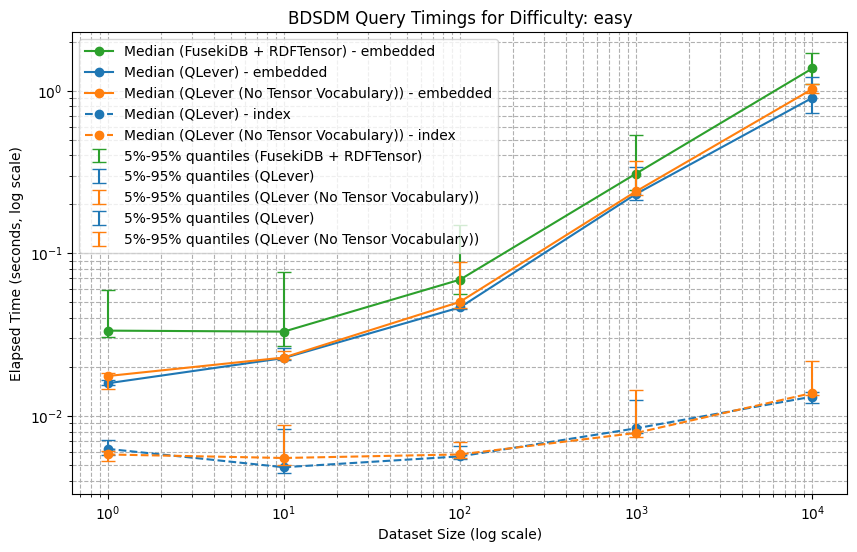

In [28]:
import matplotlib.pyplot as plt


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, median_timings, quantile_timings, engine, difficulty):
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["estimated_size"],
                engine_median["elapsed_time"],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["estimated_size"],
                engine_median["elapsed_time"],
                yerr=[
                    engine_median["elapsed_time"] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median["elapsed_time"],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, median_timings, quantile_timings, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Elapsed Time (seconds, log scale)")
    ax.set_title(f"BDSDM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bdsdm_timings.png")
plt.show()